# Atari Games - Cart Pole

The mission is to build an AI that "plays" Atari video games. I need to build 3 diffeent models that solve three different Atari games. This notebook is for the first game called Cart Pole. The goal is to train a model that plays it by balancing a pole on a cart. The subject asks for using reinforcement learning and Deep Q-networks.

## Table of contents:
* [Imports](#imports)
* [Creating environment](#enviroment)
* [Setting up statistics](#monitoring)
* [Model training](#training)
* [Training evaluation](#training_evaluation)
* [Model evaluation](#model_evaluation)

## Imports <a class="anchor" id="imports"></a>

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from gymnasium.wrappers import RecordEpisodeStatistics
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback

In [2]:
SEED = 142
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (10, 5)

## Creating enviroment <a class="anchor" id="enviroment"></a>

In [3]:
def make_training_env():
    env = gym.make("CartPole-v1")
    env = RecordEpisodeStatistics(env)
    return env

train_env = make_training_env()

## Setting up statistics <a class="anchor" id="monitoring"></a>

In [4]:
class EpisodicReturnCallback(BaseCallback):
    def __init__(self, verbose=0) -> None:
        super().__init__(verbose)
        self.episode_returns = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info: 
                ep = info["episode"]
                self.episode_returns.append(float(ep["r"]))
                self.episode_lengths.append(int(ep["l"]))
        return True

log_cb = EpisodicReturnCallback()

## Model training <a class="anchor" id="training"></a>

In [5]:
# DQN hyperparameters tuned for CartPole in RL Zoo https://stable-baselines3.readthedocs.io/en/master/guide/rl_zoo.html

dqn_kwargs = {
    "learning_rate": 2.5e-4,                    # How fast the network weights are updated  
    "batch_size": 64,                           # Number of past transitions used per training update
    "buffer_size": 100_000,                     # How many past transitions the agent remembers
    "exploration_fraction": 0.16,               # Part of training time used to reduce randomness
    "exploration_final_eps": 0.04,              # Minimum chance of picking a random action
    "gamma": 0.99,                              # How much future rewards are worth compared to immediate ones
    "gradient_steps": 128,                      # How many training updates to run at each training point
    "learning_starts": 1000,                    # How many steps to collect before starting training
    "target_update_interval": 10,               # How often to copy the network into the target network
    "train_freq": 256,                          # How often the agent trains, in environment steps
    "policy_kwargs": {"net_arch": [256, 256]},  # Two fully connected layers with 256 unit each
    "seed": SEED,
    "verbose": 0
}

model = DQN("MlpPolicy", train_env, **dqn_kwargs)

In [6]:
# Train
TOTAL_TIMESTAMPS = 50_000
model.learn(total_timesteps=TOTAL_TIMESTAMPS, callback=log_cb)

## Training evaluation <a class="anchor" id="training_evaluation"></a>

In [7]:
# Plot learning curve with rolling mean
def plot_training(returns, window=20):
    returns = np.array(returns, dtype=float)
    plt.figure()
    plt.plot(returns, label="episode return")
    if len(returns) >= window:
        cumsum = np.cumsum(np.insert(returns, 0, 0))
        rolling = (cumsum[window:] - cumsum[:-window]) / window
        # Align the rolling curve to the right edge of the window for readability
        x = np.arange(window-1, len(returns))
        plt.plot(x, rolling, label=f"rolling mean ({window})")
    plt.title("DQN on CartPole-v1 - Episode Returns")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.show()

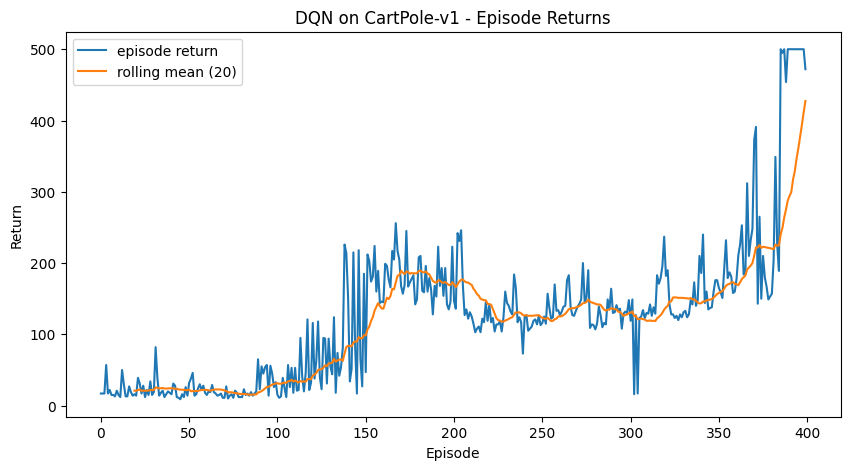

In [8]:
plot_training(log_cb.episode_returns, 20)

## Model Evaluation <a class="anchor" id="model_evaluation"></a>

In [9]:
def evaluate_greedy(model, n_episodes=5):
    # render_mode="human" will show the CartPole window
    test_env = gym.make("CartPole-v1", render_mode="human")
    scores = []
    try:
        for ep in range(n_episodes):
            # Reset with a changing seed for variety across episodes
            obs, _ = test_env.reset(seed=SEED + 100 + ep)
            terminated = False
            truncated = False
            total_r = 0.0

            while not (terminated or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = test_env.step(action)
                total_r += float(reward)

            print(f"Episode {ep + 1}: return={total_r:.1f}")
            scores.append(total_r)
    finally:
        test_env.close()

    if len(scores) > 0:
        print(f"Average return score: {np.mean(scores)} ± {np.std(scores):.1f}")

    return scores

# Run a quick check
_ = evaluate_greedy(model, 5)

/Users/nikolaykirilov/Documents/University/qwasar/atari_games/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 1: return=500.0
Episode 2: return=500.0
Episode 3: return=500.0
Episode 4: return=500.0
Episode 5: return=500.0
Average return score: 500.0 ± 0.0
